# Distillation (Teacher -> Student)

## Attempt 1:

The start of training with distillation (Teacher -> Student)...
Epoch [01/25] | Total: 3.6305 | Distill: 0.9857 | Val EER: 21.25%
Epoch [05/25] | Total: 2.0850 | Distill: 0.9277 | Val EER: 11.88%
Epoch [10/25] | Total: 1.7294 | Distill: 0.8861 | Val EER: 6.25%
Epoch [15/25] | Total: 1.4653 | Distill: 0.8749 | Val EER: 5.00%
Epoch [20/25] | Total: 1.2979 | Distill: 0.8523 | Val EER: 8.75%
Epoch [25/25] | Total: 1.1818 | Distill: 0.8449 | Val EER: 1.88%


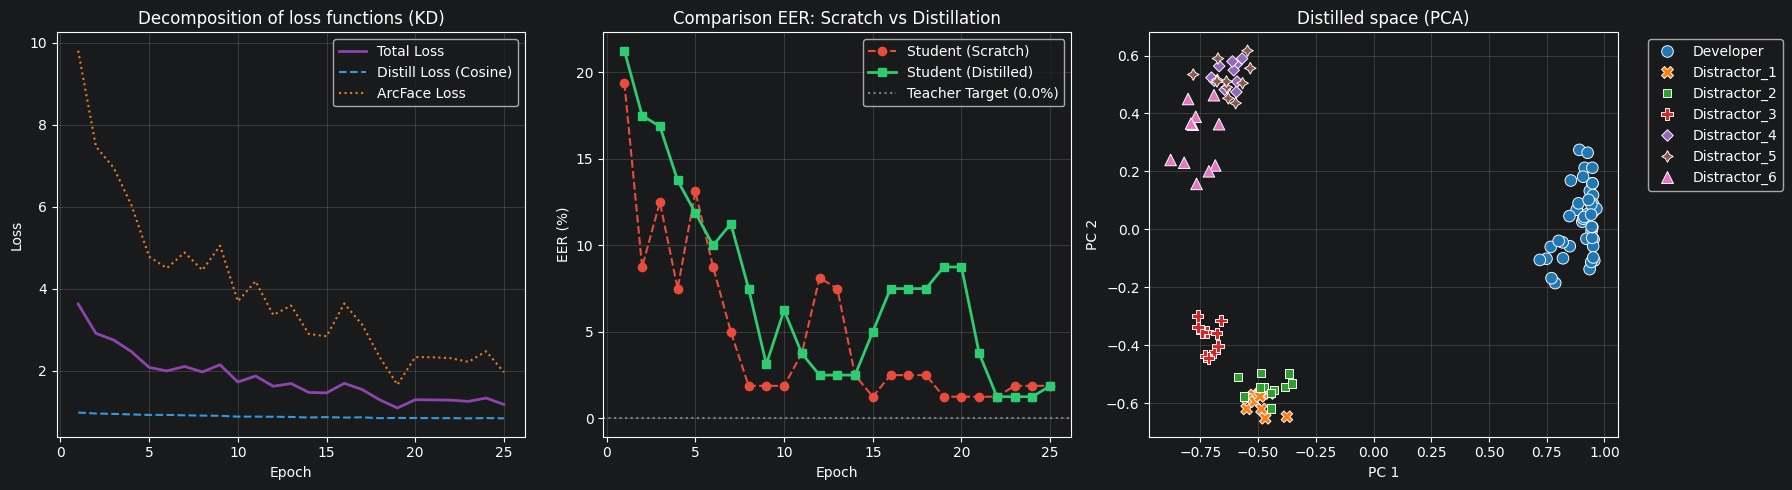

In [1]:
import os
import csv
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

import torch
from torch.utils.data import DataLoader
import torchaudio

warnings.filterwarnings("ignore")

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

from models.student.tiny_ecapa import TinyECAPA
from src.dataset import VoiceprintDataset, MelSpectrogramExtractor
from src.losses import ArcMarginProduct, DistillationLoss
from speechbrain.inference.classifiers import EncoderClassifier
from speechbrain.utils.fetching import LocalStrategy

device = "cuda:0" if torch.cuda.is_available() else "cpu"

teacher = EncoderClassifier.from_hparams(
    source="models/teacher/ecapa_voxceleb",
    savedir="models/teacher/ecapa_voxceleb",
    run_opts={"device": device},
    local_strategy=LocalStrategy.COPY
)
teacher.eval()

def extract_teacher_emb(wav_path):
    sig, fs = torchaudio.load(wav_path)
    if sig.shape[0] > 1:
        sig = torch.mean(sig, dim=0, keepdim=True)
    if fs != 16000:
        sig = torchaudio.transforms.Resample(fs, 16000)(sig)
    with torch.no_grad():
        emb = teacher.encode_batch(sig.to(device))
        emb = torch.nn.functional.normalize(emb, dim=-1).squeeze().flatten().cpu().numpy()
    return emb

train_manifest = "data/manifest/train.csv"
teacher_cache = {}
with open(train_manifest, "r", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        path = row["path"]
        if path not in teacher_cache:
            teacher_cache[path] = extract_teacher_emb(path)

class DistillVoiceprintDataset(VoiceprintDataset):
    def __init__(self, manifest_csv, cache, segment_length=32000, augment=True):
        super().__init__(manifest_csv, segment_length=segment_length, augment=augment)
        self.cache = cache

    def __getitem__(self, idx):
        mel, spk_id = super().__getitem__(idx)
        wav_path, _ = self.samples[idx]
        t_emb = torch.tensor(self.cache[wav_path], dtype=torch.float32)
        return mel, t_emb, spk_id

train_dataset = DistillVoiceprintDataset(train_manifest, teacher_cache, segment_length=32000, augment=True)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, drop_last=True)

val_pairs = []
with open("data/manifest/val_pairs.csv", "r", encoding="utf-8") as f:
    for r in csv.DictReader(f):
        val_pairs.append((r["path1"], r["path2"], int(r["label"])))

student = TinyECAPA(in_features=80, channels=128, emb_dim=192).to(device)
arcface = ArcMarginProduct(in_features=192, out_features=7, s=30.0, m=0.30).to(device)
distill_loss_fn = DistillationLoss(alpha=0.3)

optimizer = torch.optim.AdamW(
    list(student.parameters()) + list(arcface.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-5)
extractor = MelSpectrogramExtractor()

def get_student_emb(path):
    sig, fs = torchaudio.load(path)
    mel = extractor(sig, fs).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = student(mel).squeeze().cpu().numpy()
    return emb

def compute_val_eer():
    cache = {}
    scores = []
    labels = []
    for p1, p2, label in val_pairs:
        if p1 not in cache:
            cache[p1] = get_student_emb(p1)
        if p2 not in cache:
            cache[p2] = get_student_emb(p2)
        scores.append(float(np.dot(cache[p1], cache[p2])))
        labels.append(label)

    scores = np.array(scores)
    labels = np.array(labels)
    thresholds = np.linspace(-0.2, 1.0, 500)
    far = [np.mean(scores[labels == 0] >= t) for t in thresholds]
    frr = [np.mean(scores[labels == 1] < t) for t in thresholds]
    idx = np.nanargmin(np.abs(np.array(far) - np.array(frr)))
    return (far[idx] + frr[idx]) / 2.0

EPOCHS = 25
total_loss_hist = []
cls_loss_hist = []
dist_loss_hist = []
kd_eer_hist = []

print("The start of training with distillation (Teacher -> Student)...")
for epoch in range(1, EPOCHS + 1):
    student.train()
    arcface.train()

    e_total, e_cls, e_dist = [], [], []

    for mels, t_embs, spk_ids in train_loader:
        mels = mels.to(device)
        t_embs = t_embs.to(device)
        spk_ids = spk_ids.to(device)

        optimizer.zero_grad()
        s_embs = student(mels)
        s_logits = arcface(s_embs, spk_ids)

        total_loss, loss_cls, loss_dist = distill_loss_fn(s_logits, s_embs, t_embs, spk_ids)

        total_loss.backward()
        optimizer.step()

        e_total.append(total_loss.item())
        e_cls.append(loss_cls.item())
        e_dist.append(loss_dist.item())

    scheduler.step()

    student.eval()
    val_eer = compute_val_eer()

    total_loss_hist.append(np.mean(e_total))
    cls_loss_hist.append(np.mean(e_cls))
    dist_loss_hist.append(np.mean(e_dist))
    kd_eer_hist.append(val_eer * 100)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] | Total: {np.mean(e_total):.4f} | Distill: {np.mean(e_dist):.4f} | Val EER: {val_eer * 100:.2f}%")

os.makedirs("models/student", exist_ok=True)
torch.save(student.state_dict(), "models/student/tiny_ecapa_distilled.pth")

scratch_eer_hist = [19.38, 8.75, 12.50, 7.50, 13.12, 8.75, 5.00, 1.88, 1.88, 1.88, 3.75, 8.12, 7.50, 2.50, 1.25, 2.50, 2.50, 2.50, 1.25, 1.25, 1.25, 1.25, 1.88, 1.88, 1.88]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(range(1, EPOCHS + 1), total_loss_hist, label="Total Loss", color="#8e44ad", lw=2)
axes[0].plot(range(1, EPOCHS + 1), dist_loss_hist, label="Distill Loss (Cosine)", color="#3498db", linestyle="--")
axes[0].plot(range(1, EPOCHS + 1), cls_loss_hist, label="ArcFace Loss", color="#e67e22", linestyle=":")
axes[0].set_title("Decomposition of loss functions (KD)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, EPOCHS + 1), scratch_eer_hist, label="Student (Scratch)", color="#e74c3c", linestyle="--", marker="o")
axes[1].plot(range(1, EPOCHS + 1), kd_eer_hist, label="Student (Distilled)", color="#2ecc71", lw=2, marker="s")
axes[1].axhline(0.0, color="gray", linestyle=":", label="Teacher Target (0.0%)")
axes[1].set_title("Comparison EER: Scratch vs Distillation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("EER (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

all_embs = []
all_labels = []
with open(train_manifest, "r", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        all_embs.append(get_student_emb(row["path"]))
        all_labels.append("Developer" if row["speaker_id"] == "0" else f"Distractor_{row['speaker_id']}")

pca = PCA(n_components=2)
reduced = pca.fit_transform(np.array(all_embs))

sns.scatterplot(
    x=reduced[:, 0], y=reduced[:, 1],
    hue=all_labels, style=all_labels,
    palette="tab10", s=70, ax=axes[2]
)
axes[2].set_title("Distilled space (PCA)")
axes[2].set_xlabel("PC 1")
axes[2].set_ylabel("PC 2")
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The top‑tier distillation method didn’t work, so we’ll have to try something else. In the ArcFace formula, the scaling factor is s = 30.0. Because of this, the classifier’s gradients turned out to be 30 times more powerful than the gradients from the cosine loss. Even with a weight of alpha = 0.3, the classification crushed distillation at every step.
Convert the distillation loss to MSE (Mean Squared Error) alignment between normalized vectors with an increased weight (*10), or we reduce the influence of ArcFace to a purely symbolic alpha = 0.05. The student must first copy the Teacher’s model, rather than inventing their own projections.

## Attempt 2:

The start of calibrated training with distillation...
Epoch [01/80] | Total: 0.6734 | Distill (MSE*20): 0.2037 | Val EER: 21.88%
Epoch [10/80] | Total: 0.3741 | Distill (MSE*20): 0.1699 | Val EER: 11.88%
Epoch [20/80] | Total: 0.3313 | Distill (MSE*20): 0.1548 | Val EER: 2.50%
Epoch [30/80] | Total: 0.2384 | Distill (MSE*20): 0.1361 | Val EER: 0.00%
Epoch [40/80] | Total: 0.2050 | Distill (MSE*20): 0.1308 | Val EER: 0.00%
Epoch [50/80] | Total: 0.1865 | Distill (MSE*20): 0.1235 | Val EER: 1.25%
Epoch [60/80] | Total: 0.1905 | Distill (MSE*20): 0.1200 | Val EER: 0.00%
Epoch [70/80] | Total: 0.1379 | Distill (MSE*20): 0.1160 | Val EER: 0.00%
Epoch [80/80] | Total: 0.1352 | Distill (MSE*20): 0.1188 | Val EER: 0.00%


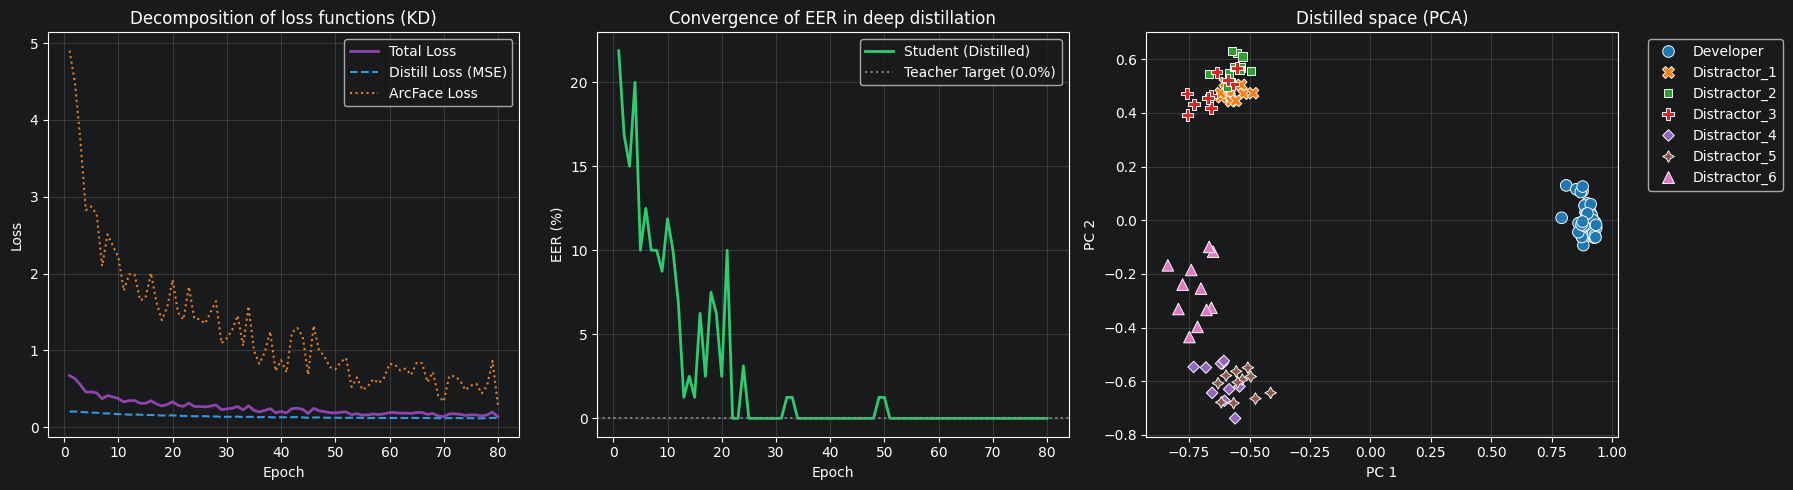

In [2]:
import os
import csv
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchaudio

warnings.filterwarnings("ignore")

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

from models.student.tiny_ecapa import TinyECAPA
from src.dataset import VoiceprintDataset, MelSpectrogramExtractor
from src.losses import ArcMarginProduct
from speechbrain.inference.classifiers import EncoderClassifier
from speechbrain.utils.fetching import LocalStrategy

device = "cuda:0" if torch.cuda.is_available() else "cpu"

teacher = EncoderClassifier.from_hparams(
    source="models/teacher/ecapa_voxceleb",
    savedir="models/teacher/ecapa_voxceleb",
    run_opts={"device": device},
    local_strategy=LocalStrategy.COPY
)
teacher.eval()

def extract_teacher_emb(wav_path):
    sig, fs = torchaudio.load(wav_path)
    if sig.shape[0] > 1:
        sig = torch.mean(sig, dim=0, keepdim=True)
    if fs != 16000:
        sig = torchaudio.transforms.Resample(fs, 16000)(sig)
    with torch.no_grad():
        emb = teacher.encode_batch(sig.to(device))
        emb = F.normalize(emb, dim=-1).squeeze().flatten().cpu().numpy()
    return emb

train_manifest = "data/manifest/train.csv"
teacher_cache = {}
with open(train_manifest, "r", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        path = row["path"]
        if path not in teacher_cache:
            teacher_cache[path] = extract_teacher_emb(path)

class DistillVoiceprintDataset(VoiceprintDataset):
    def __init__(self, manifest_csv, cache, segment_length=32000, augment=True):
        super().__init__(manifest_csv, segment_length=segment_length, augment=augment)
        self.cache = cache

    def __getitem__(self, idx):
        mel, spk_id = super().__getitem__(idx)
        wav_path, _ = self.samples[idx]
        t_emb = torch.tensor(self.cache[wav_path], dtype=torch.float32)
        return mel, t_emb, spk_id

train_dataset = DistillVoiceprintDataset(train_manifest, teacher_cache, segment_length=32000, augment=True)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, drop_last=True)

val_pairs = []
with open("data/manifest/val_pairs.csv", "r", encoding="utf-8") as f:
    for r in csv.DictReader(f):
        val_pairs.append((r["path1"], r["path2"], int(r["label"])))

student = TinyECAPA(in_features=80, channels=128, emb_dim=192).to(device)
arcface = ArcMarginProduct(in_features=192, out_features=7, s=15.0, m=0.25).to(device)

criterion_cls = nn.CrossEntropyLoss()
criterion_distill = nn.MSELoss()

optimizer = torch.optim.AdamW(
    list(student.parameters()) + list(arcface.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

EPOCHS = 80
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
extractor = MelSpectrogramExtractor()

def get_student_emb(path):
    sig, fs = torchaudio.load(path)
    mel = extractor(sig, fs).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = student(mel).squeeze().cpu().numpy()
    return emb

def compute_val_eer():
    cache = {}
    scores = []
    labels = []
    for p1, p2, label in val_pairs:
        if p1 not in cache:
            cache[p1] = get_student_emb(p1)
        if p2 not in cache:
            cache[p2] = get_student_emb(p2)
        scores.append(float(np.dot(cache[p1], cache[p2])))
        labels.append(label)

    scores = np.array(scores)
    labels = np.array(labels)
    thresholds = np.linspace(-0.2, 1.0, 500)
    far = [np.mean(scores[labels == 0] >= t) for t in thresholds]
    frr = [np.mean(scores[labels == 1] < t) for t in thresholds]
    idx = np.nanargmin(np.abs(np.array(far) - np.array(frr)))
    return (far[idx] + frr[idx]) / 2.0

total_loss_hist = []
cls_loss_hist = []
dist_loss_hist = []
kd_eer_hist = []

print("The start of calibrated training with distillation...")
for epoch in range(1, EPOCHS + 1):
    student.train()
    arcface.train()

    e_total, e_cls, e_dist = [], [], []

    for mels, t_embs, spk_ids in train_loader:
        mels = mels.to(device)
        t_embs = t_embs.to(device)
        spk_ids = spk_ids.to(device)

        optimizer.zero_grad()
        s_embs = student(mels)
        s_logits = arcface(s_embs, spk_ids)

        loss_cls = criterion_cls(s_logits, spk_ids)
        loss_dist = criterion_distill(s_embs, t_embs) * 20.0

        total_loss = 0.1 * loss_cls + 0.9 * loss_dist

        total_loss.backward()
        optimizer.step()

        e_total.append(total_loss.item())
        e_cls.append(loss_cls.item())
        e_dist.append(loss_dist.item())

    scheduler.step()

    student.eval()
    val_eer = compute_val_eer()

    total_loss_hist.append(np.mean(e_total))
    cls_loss_hist.append(np.mean(e_cls))
    dist_loss_hist.append(np.mean(e_dist))
    kd_eer_hist.append(val_eer * 100)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] | Total: {np.mean(e_total):.4f} | Distill (MSE*20): {np.mean(e_dist):.4f} | Val EER: {val_eer * 100:.2f}%")

os.makedirs("models/student", exist_ok=True)
torch.save(student.state_dict(), "models/student/tiny_ecapa_distilled.pth")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(range(1, EPOCHS + 1), total_loss_hist, label="Total Loss", color="#8e44ad", lw=2)
axes[0].plot(range(1, EPOCHS + 1), dist_loss_hist, label="Distill Loss (MSE)", color="#3498db", linestyle="--")
axes[0].plot(range(1, EPOCHS + 1), cls_loss_hist, label="ArcFace Loss", color="#e67e22", linestyle=":")
axes[0].set_title("Decomposition of loss functions (KD)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, EPOCHS + 1), kd_eer_hist, label="Student (Distilled)", color="#2ecc71", lw=2)
axes[1].axhline(0.0, color="gray", linestyle=":", label="Teacher Target (0.0%)")
axes[1].set_title("Convergence of EER in deep distillation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("EER (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

all_embs = []
all_labels = []
with open(train_manifest, "r", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        all_embs.append(get_student_emb(row["path"]))
        all_labels.append("Developer" if row["speaker_id"] == "0" else f"Distractor_{row['speaker_id']}")

pca = PCA(n_components=2)
reduced = pca.fit_transform(np.array(all_embs))

sns.scatterplot(
    x=reduced[:, 0], y=reduced[:, 1],
    hue=all_labels, style=all_labels,
    palette="tab10", s=70, ax=axes[2]
)
axes[2].set_title("Distilled space (PCA)")
axes[2].set_xlabel("PC 1")
axes[2].set_ylabel("PC 2")
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()